<a href="https://colab.research.google.com/github/Givi-Modebadze/ML_Final_Project/blob/main/experiments/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'ML_Final_Project/walmart-recruiting-store-sales-forecasting'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME/

Mounted at /content/drive
/content/drive/My Drive/ML_Final_Project/walmart-recruiting-store-sales-forecasting


In [2]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cpu


# Merge data

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

def merger(df, stores, features):
    df = df.merge(stores, how='left', on='Store')
    df = df.merge(features, how='left', on=['Store', 'Date', 'IsHoliday'])
    return df

df = merger(df, stores, features)
test = merger(test, stores, features)

df.sort_values('Date', inplace=True)
test.sort_values('Date', inplace=True)

y = df['Weekly_Sales']
X = df.drop(columns=['Weekly_Sales'])
dates = df['Date']

# Preprocessor

In [4]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class Preprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.type_encoder = None

    def fit(self, X: pd.DataFrame, y=None):
        if 'Type' in X.columns:
            self.type_encoder = X['Type'].astype('category').cat.categories
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()

        X['Date'] = pd.to_datetime(X['Date'])
        X['Year'] = X['Date'].dt.year
        X['Month'] = X['Date'].dt.month
        X['Day'] = X['Date'].dt.day

        if self.type_encoder is not None:
            X['Type'] = pd.Categorical(X['Type'], categories=self.type_encoder)
            X['Type'] = X['Type'].cat.codes

        if 'IsHoliday' in X.columns:
            X['IsHoliday'] = X['IsHoliday'].astype(int)

        X = X.fillna(0)

        X = X.drop(columns=['Date'], errors='ignore')

        return X


# cross validation

In [5]:
def weighted_mae(y_true, y_pred, is_holiday):
    weights = is_holiday * 4 + 1
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

def cross_validation(pipeline, X, y, df_with_dates):
    from matplotlib.dates import DateFormatter

    tscv = TimeSeriesSplit(n_splits=6)
    rmse_scores = []
    wmae_scores = []
    train_rmse_scores = []
    train_wmae_scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        if fold < 4:
          continue

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_train, y_train)

        y_val_pred = pipeline.predict(X_val)
        y_train_pred = pipeline.predict(X_train)

        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

        val_is_holiday = df_with_dates.iloc[val_idx]['IsHoliday'].astype(int)
        train_is_holiday = df_with_dates.iloc[train_idx]['IsHoliday'].astype(int)

        val_wmae = weighted_mae(y_val, y_val_pred, val_is_holiday)
        train_wmae = weighted_mae(y_train, y_train_pred, train_is_holiday)

        print(f"\nFold {fold + 1} Scores:")
        print(f"Train RMSE: {train_rmse:.2f} | Train WMAE: {train_wmae:.2f}")
        print(f"Valid RMSE: {val_rmse:.2f} | Valid WMAE: {val_wmae:.2f}")

        rmse_scores.append(val_rmse)
        wmae_scores.append(val_wmae)
        train_rmse_scores.append(train_rmse)
        train_wmae_scores.append(train_wmae)

        df_all = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates['Date']),
            'y': y.values
        })
        df_all = df_all.groupby('Date').sum().reset_index().sort_values('Date')

        df_val = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates.iloc[val_idx]['Date']),
            'Actual': y_val.values,
            'Predicted': y_val_pred
        }).groupby('Date').sum().reset_index().sort_values('Date')

        df_train = pd.DataFrame({
            'Date': pd.to_datetime(df_with_dates.iloc[train_idx]['Date']),
            'Actual': y_train.values,
            'Predicted': y_train_pred
        }).groupby('Date').sum().reset_index().sort_values('Date')

        plt.figure(figsize=(12, 4))

        plt.plot(df_all['Date'], df_all['y'], color='gray', label='Train Actuals', linewidth=1.5, alpha=0.4)

        plt.plot(df_train['Date'], df_train['Predicted'], color='green', label='Train Predicted', linewidth=1.5, alpha=0.8)

        plt.plot(df_val['Date'], df_val['Actual'], color='blue', label='Val Actuals', linewidth=2)

        plt.plot(df_val['Date'], df_val['Predicted'], color='orange', label='Val Predicted', linewidth=2)

        plt.title(f'Fold {fold + 1} - Weekly Sales Over Time', fontsize=14)
        plt.xlabel("Date")
        plt.ylabel("Weekly Sales")
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    print(f"\nMean Train RMSE: {np.mean(train_rmse_scores):.2f}")
    print(f"Mean Train WMAE: {np.mean(train_wmae_scores):.2f}")
    print(f"Mean Valid RMSE: {np.mean(rmse_scores):.2f}")
    print(f"Mean Valid WMAE: {np.mean(wmae_scores):.2f}")


# Pipeline


Fold 5 Scores:
Train RMSE: 1483.16 | Train WMAE: 634.54
Valid RMSE: 4720.24 | Valid WMAE: 2102.12


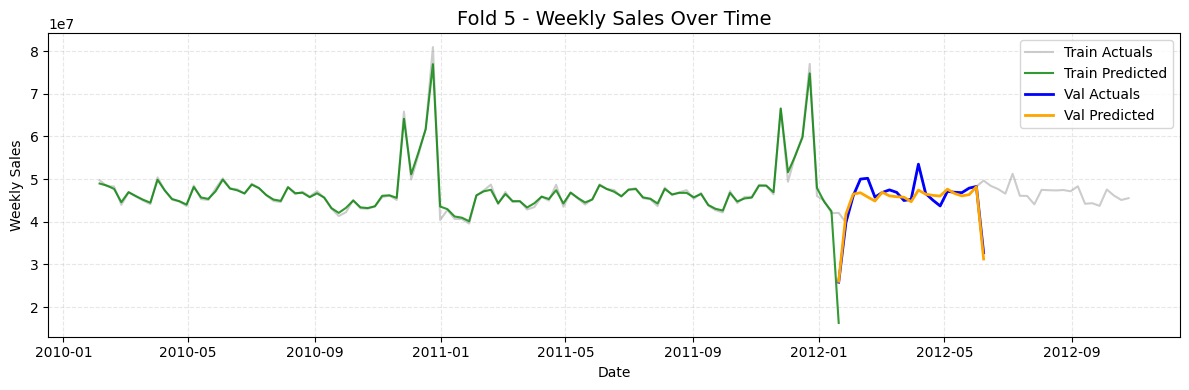


Fold 6 Scores:
Train RMSE: 1418.08 | Train WMAE: 607.88
Valid RMSE: 3504.63 | Valid WMAE: 1708.00


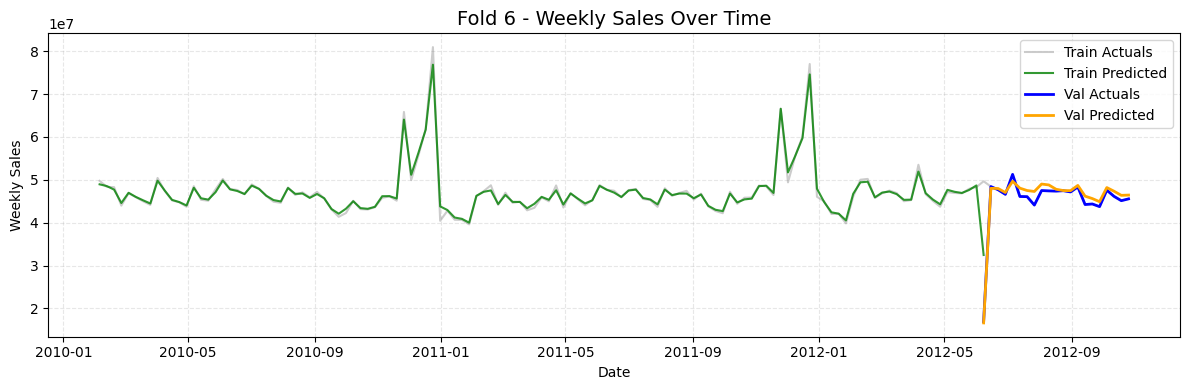


Mean Train RMSE: 1450.62
Mean Train WMAE: 621.21
Mean Valid RMSE: 4112.44
Mean Valid WMAE: 1905.06


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

preprocessor = Preprocessor()
model = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=30 , n_jobs=-1)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

cross_validation(pipeline, X, y, df)

In [21]:
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor', Preprocessor()),
                ('model',
                 RandomForestRegressor(max_depth=30, n_estimators=50, n_jobs=-1,
                                       random_state=42))])

In [9]:
!pip install dagshub
!pip install "mlflow<3"

import mlflow
import dagshub

dagshub.init(repo_owner='gbend22', repo_name='ML_Final_Project', mlflow=True)

experiment = "Final Project Random Forest"
mlflow.set_experiment(experiment)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=9e48bfcd-99c6-417a-a79f-b9880a98ecb1&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=c8dd9dd5fe788d0e5557c2b4c1808b5b858097ff68c694dde514906c29376549




Accessing as gbend22

Initialized MLflow to track repo "gbend22/ML_Final_Project"

Repository gbend22/ML_Final_Project initialized!

2025/07/17 06:37:14 INFO mlflow.tracking.fluent: Experiment with name 'Final Project Random Forest' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/4069db5d9042421bb4da6db6cf3d38bf', creation_time=1752734234744, experiment_id='1', last_update_time=1752734234744, lifecycle_stage='active', name='Final Project Random Forest', tags={}>

In [22]:
with mlflow.start_run(run_name="lower_max_depth") as run:
    mlflow.sklearn.log_model(
        sk_model=pipeline,
        artifact_path="random_forest_pipeline_model",
        registered_model_name="RandomForestPipelineModel"
    )

    mlflow.log_params({
        "n_estimators": 50,
        "n_jobs": -1,
        "max_depth": 30,
        "random_state": 42
    })

    mlflow.log_metrics({
        "Mean Train RMSE" : 1450.62,
        "Mean Train WMAE" : 621.21,
        "Mean Valid RMSE" : 4112.44,
        "Mean Valid WMAE" : 1905.06,
    })

2025/07/17 07:30:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'RandomForestPipelineModel' already exists. Creating a new version of this model...
2025/07/17 07:31:10 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RandomForestPipelineModel, version 5
Created version '5' of model 'RandomForestPipelineModel'.


🏃 View run lower_max_depth at: https://dagshub.com/gbend22/ML_Final_Project.mlflow/#/experiments/1/runs/82b6de33bb98405a8839fe4fa5d8dea9
🧪 View experiment at: https://dagshub.com/gbend22/ML_Final_Project.mlflow/#/experiments/1
